# Semantic spaces of the natural languages and their intrinsic dimensions: comparative analysis

**Authors:** Vasilii A. Gromov, Inna V. Skrynnikova, Alexandra S. Kogan,  and Artem I. Serikov

In [2]:
import numpy as np
import pandas as pd
from Wishart import Wishart
from scipy.stats import chi2_contingency
from sklearn.metrics import calinski_harabasz_score, adjusted_rand_score
from sklearn.manifold import TSNE
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

data_path = 'data'

## I. Clustering

In [3]:
ec, id = pd.read_csv(f'{data_path}/EC.csv'), pd.read_csv(f'{data_path}/ID.csv')

ec.shape, id.shape

((122, 5), (427, 9))

In [4]:
def cluster(n, d, neighbours, alphas, table):
    X = table[(table.n == n) & (table.d == d)].drop('language', axis=1)

    scores, global_labels = [], []
    for neighs in neighbours:
        for alpha in alphas:
            model = Wishart(wishart_neighbors=neighs, significance_level=alpha)

            labels = model.fit(X)
            global_labels.append(labels)

            try: scores.append(calinski_harabasz_score(X, labels))
            except ValueError: scores.append(-1)

    return scores, global_labels


neighbours = np.arange(1, 16)
alphas = np.arange(0.001, 0.101, 0.001)

### EC clustering ###
scores_ec, labels_ec, best_params_ec = [], [], []

for d in (4, 5):
    scores, labels = cluster(3, d, neighbours, alphas, ec)

    best_num = np.argmax(scores)

    scores_ec.append(scores[best_num])
    labels_ec.append(labels[best_num])

    best_params_ec.append([
        neighbours[best_num // alphas.shape[0]], alphas[best_num % alphas.shape[0]]
    ])

### ID clustering ###
scores_id, labels_id, best_params_id = [], [], []

for n in (1, 2, 3):
    for d in (5, 10, 15):
        if n == 3 and d != 15: continue

        scores, labels = cluster(n, d, neighbours, alphas, id)

        best_num = np.argmax(scores)

        scores_id.append(scores[best_num])
        labels_id.append(labels[best_num])

        best_params_id.append([
            neighbours[best_num // alphas.shape[0]], alphas[best_num % alphas.shape[0]]
        ])

In [5]:
def print_clusters(labels, table):
    languages = np.unique(table.language.values)

    for i, label in enumerate(np.unique(labels)):
        cluster = languages[labels == label]
        print(f'Cluster {i + 1}: {', '.join(cluster)}')
    print()

for i, n in enumerate((1, 2, 3)):
    for j, d in enumerate((5, 10, 15)):
        if n == 3 and d != 15: continue
        if n == 3 and d == 15: j = 0

        print('---------------------------------------------------------------')
        print(f'n = {n}, d = {d}')
        print(f'ch_score = {scores_id[i * 3 + j].round(3)}')

        neighs, alpha = best_params_id[i * 3 + j]
        print(f'best params: = {neighs}, {alpha}\n')

        print_clusters(labels_id[i * 3 + j], id)

---------------------------------------------------------------
n = 1, d = 5
ch_score = 16.706
best params: = 1, 0.001

Cluster 1: Japanese, Kazakh, Malayalam, Norwegian
Cluster 2: Bengali, Bulgarian, Chinese, Dutch, Navajo, Ossetian, Slovak, Spanish, Tabasaran, Tatar
Cluster 3: Basque, Czech, French, Latin, Sinhala, Swahili, Vietnamese
Cluster 4: Estonian, Portuguese
Cluster 5: Arabic, English, Latvian, Russian, Serbian, Tagalog
Cluster 6: Belarus, Finnish, Korean, Turkish, Ukrainian, Uzbek
Cluster 7: Icelandic, Thai, Udmurt
Cluster 8: Indonesian, Polish
Cluster 9: Chechen, German, Italian, Komi-Zyrian, Persian, Swedish
Cluster 10: Amharic, Bamana (Bambara), Coptic, Dholuo, Esperanto, Kyrgyz, Punjabi, Romanian
Cluster 11: Slovenian, Tuvan
Cluster 12: Hindi, Hungarian, Kabyle
Cluster 13: Atikamekw, Quechua

---------------------------------------------------------------
n = 1, d = 10
ch_score = 18.369
best params: = 1, 0.001

Cluster 1: English, Indonesian, Kabyle, Polish, Portuguese, 

## II. Classification analysis

In [6]:
clustering = pd.DataFrame(
    np.vstack((ec[(ec.n == 3) & (ec.d == 4)].language, labels_id, labels_ec)).T,
    columns=(
        'language', 'ID 1x5', 'ID 1x10', 'ID 1x15', 'ID 2x5',
        'ID 2x10', 'ID 2x15', 'ID 3x15', 'EC 3x4', 'EC 3x5'
    )
)

clustering.head(5)

,language,ID 1x5,ID 1x10,ID 1x15,ID 2x5,ID 2x10,ID 2x15,ID 3x15,EC 3x4,EC 3x5
0,Amharic,10,15,3,15,1,3,5,2,8
1,Arabic,5,2,3,5,6,8,1,6,9
2,Atikamekw,13,12,13,18,15,18,4,14,5
3,Bamana (Bambara),10,2,8,2,6,5,2,13,9
4,Basque,3,14,12,10,10,15,8,13,15


In [7]:
classes = pd.read_csv(f'{data_path}/classifications.csv')

classes['parametric'] = classes['Subject side'] + '/' + classes['Null subject / Pro-drop'] + '/' + \
                        classes['Compounding (TCP)'] + '/' + classes['Nominal mapping'] + '/' + classes['Wh-movement']

classes = classes[['language', 'language family', 'areal', 'parametric']]

classes.head()

,language,language family,areal,parametric
0,Amharic,Afroasiatic,Ethiopian,SOV/CNSL/-TCP/FM/Wh-Movement
1,Arabic,Afroasiatic,Berber-Arabic,SVO/CNSL/-TCP/CM/Wh-Movement
2,Atikamekw,Algic,Central Algonquian,SOV/CNSL/+TCP/FM/Wh-in-situ
3,Bamana (Bambara),Niger-Congo,West African,SOV/NNSL/-TCP/FM/Wh-in-situ
4,Basque,Isolate,Isolate,SOV/CNSL/-TCP/FM/Wh-Movement


In [8]:
res = clustering.join(classes.set_index('language'), on='language', how='inner')
res.head()

,language,ID 1x5,ID 1x10,ID 1x15,ID 2x5,ID 2x10,ID 2x15,ID 3x15,EC 3x4,EC 3x5,language family,areal,parametric
0,Amharic,10,15,3,15,1,3,5,2,8,Afroasiatic,Ethiopian,SOV/CNSL/-TCP/FM/Wh-Movement
1,Arabic,5,2,3,5,6,8,1,6,9,Afroasiatic,Berber-Arabic,SVO/CNSL/-TCP/CM/Wh-Movement
2,Atikamekw,13,12,13,18,15,18,4,14,5,Algic,Central Algonquian,SOV/CNSL/+TCP/FM/Wh-in-situ
3,Bamana (Bambara),10,2,8,2,6,5,2,13,9,Niger-Congo,West African,SOV/NNSL/-TCP/FM/Wh-in-situ
4,Basque,3,14,12,10,10,15,8,13,15,Isolate,Isolate,SOV/CNSL/-TCP/FM/Wh-Movement


In [9]:
def cramers_v(x, y):
    contingency_table = pd.crosstab(x, y)
    chi2_statistic, p_value, dof, expected = chi2_contingency(contingency_table)

    n = contingency_table.sum().sum()
    phi2 = chi2_statistic / n
    r, k = contingency_table.shape
    phi2corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    k_corr = k - (k - 1) * (k - 2) / (n - 1)
    r_corr = r - (r - 1) * (r - 2) / (n - 1)
    v = np.sqrt(phi2corr / min(k_corr - 1, r_corr - 1))

    return v

categorical_vars = res.columns

cramers_v_matrix = pd.DataFrame(index=categorical_vars, columns=categorical_vars)

for var1 in categorical_vars:
    for var2 in categorical_vars:
        cramers_v_matrix.loc[var1, var2] = cramers_v(res[var1], res[var2]).round(3)

cramers_v_matrix.loc['EC 3x4':, 'ID 1x5':'ID 3x15']

,ID 1x5,ID 1x10,ID 1x15,ID 2x5,ID 2x10,ID 2x15,ID 3x15
EC 3x4,0.0,0.0,0.245,0.0,0.239,0.117,0.156
EC 3x5,0.065,0.0,0.114,0.051,0.117,0.074,0.0
language family,0.14,0.154,0.126,0.262,0.336,0.301,0.206
areal,0.0,0.209,0.0,0.141,0.286,0.211,0.0
parametric,0.0,0.265,0.274,0.23,0.263,0.122,0.216


## III. Visualization

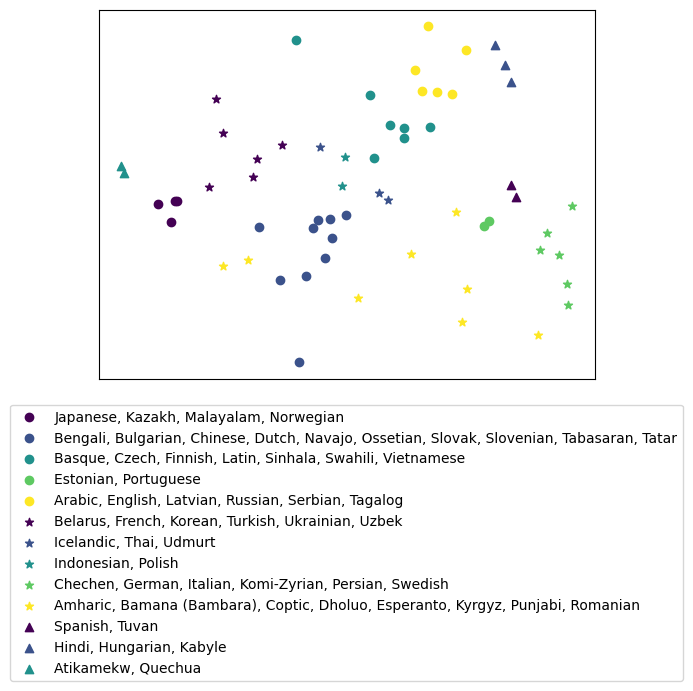

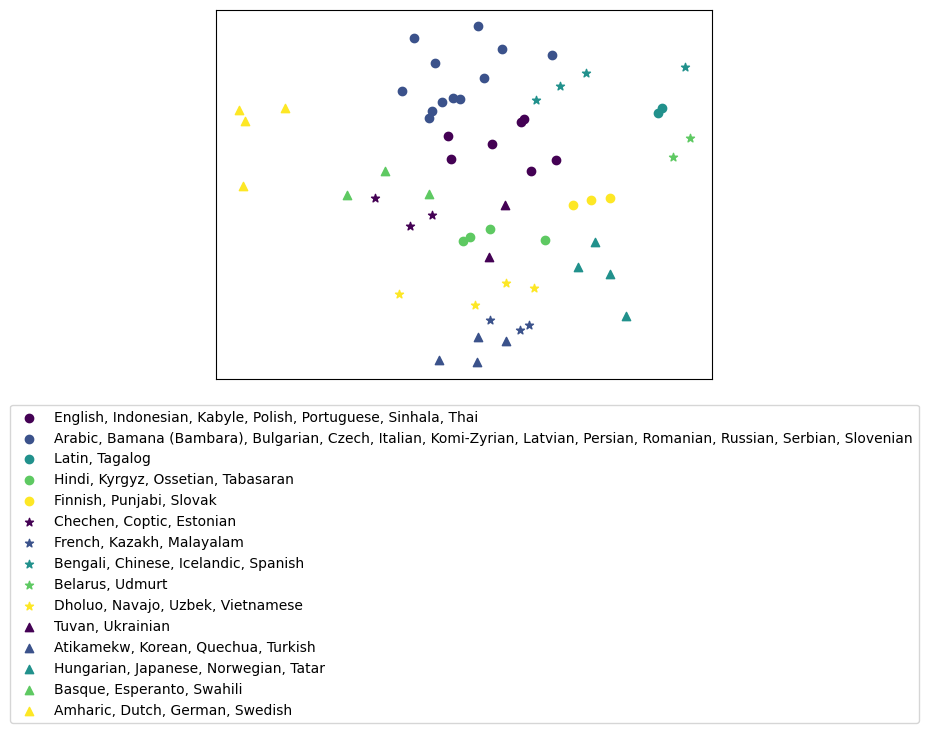

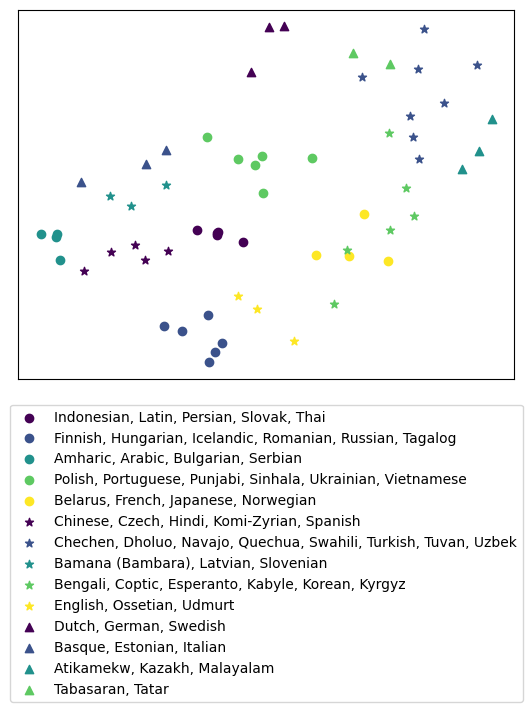

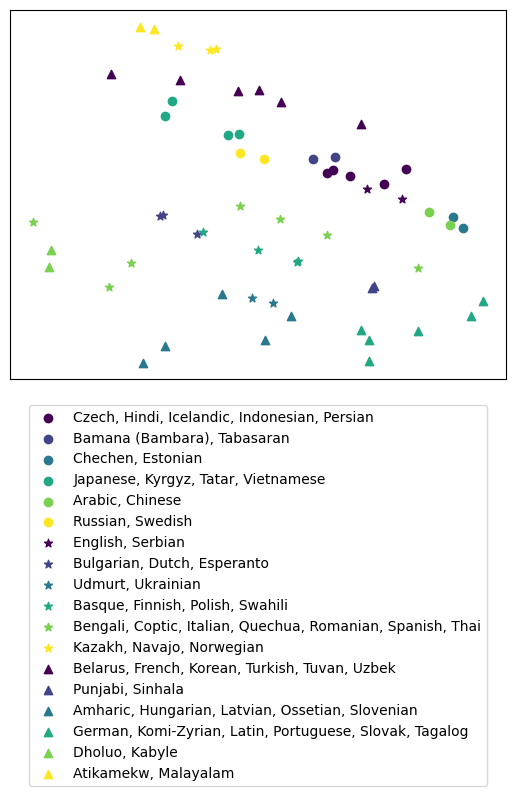

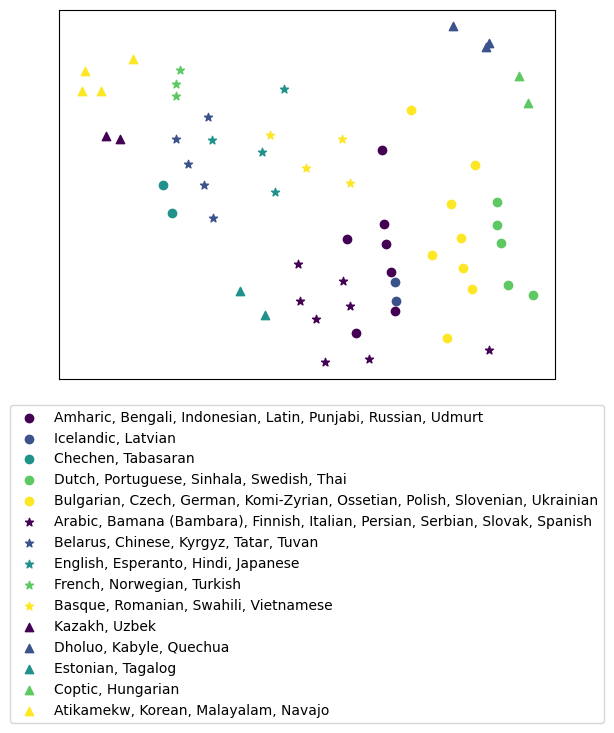

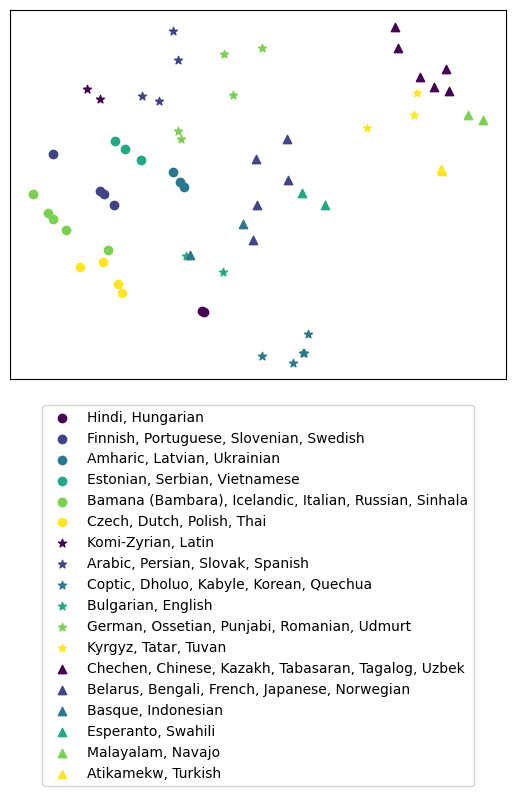

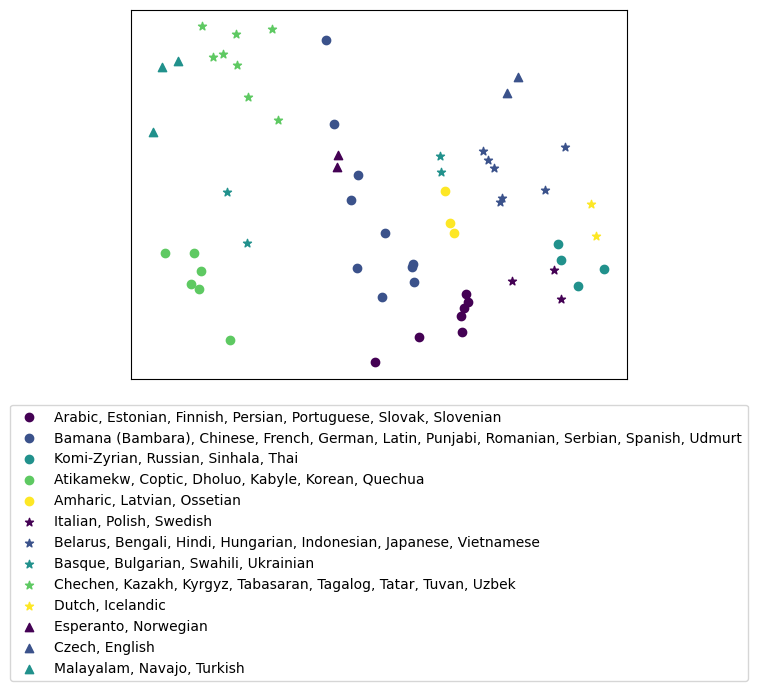

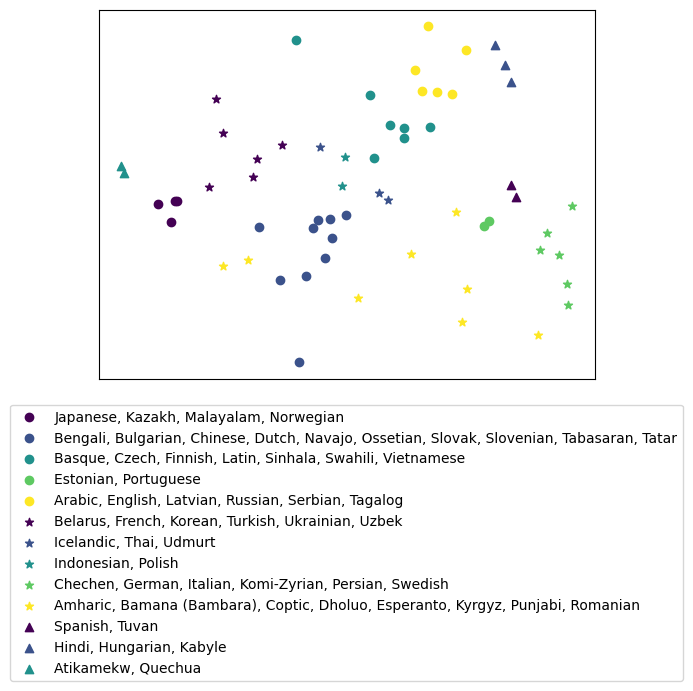

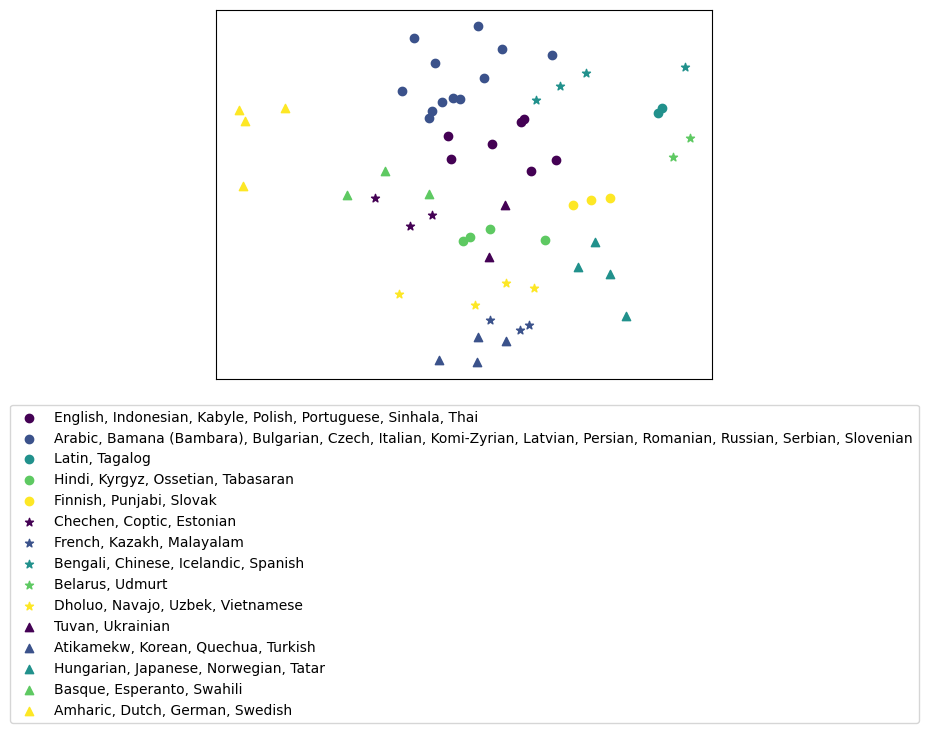

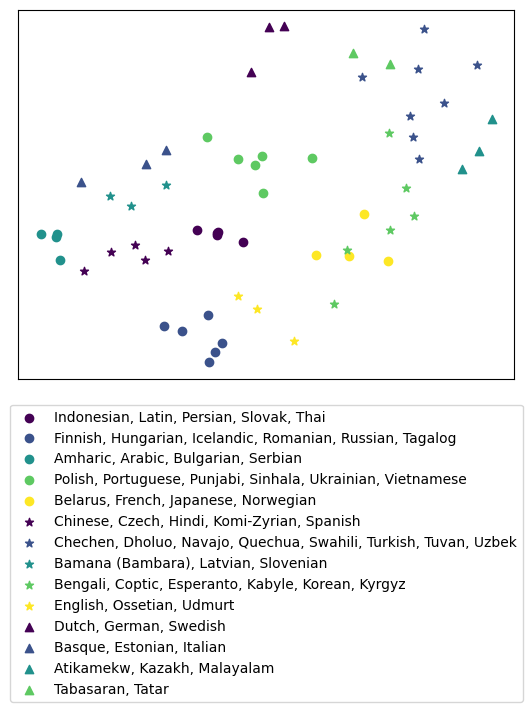

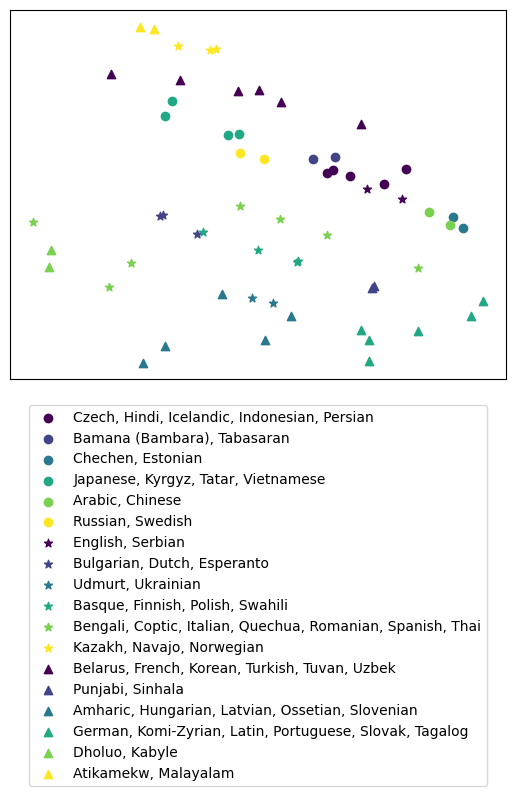

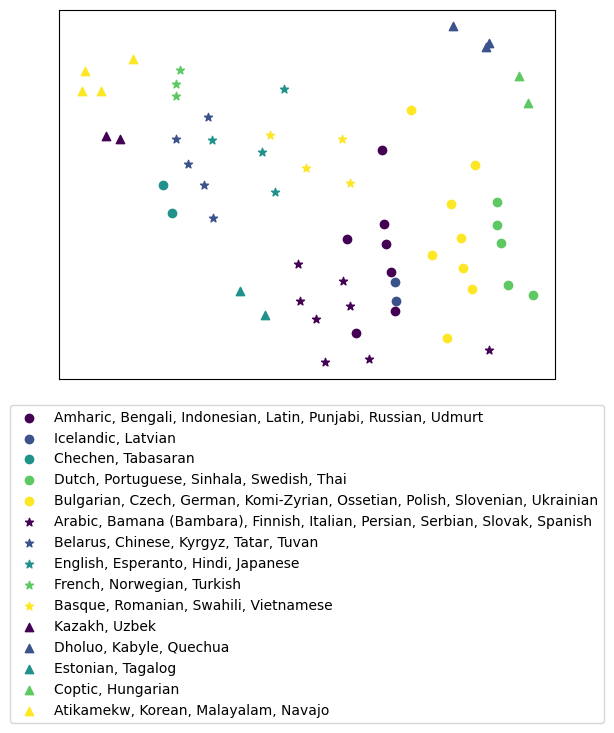

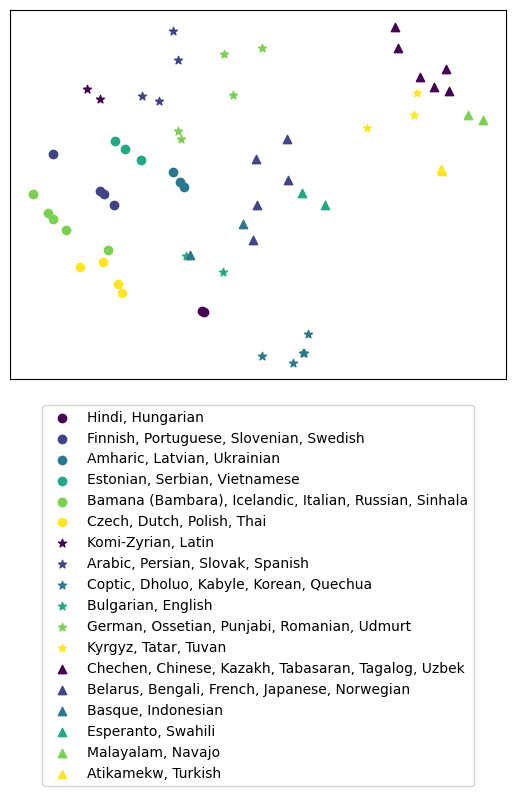

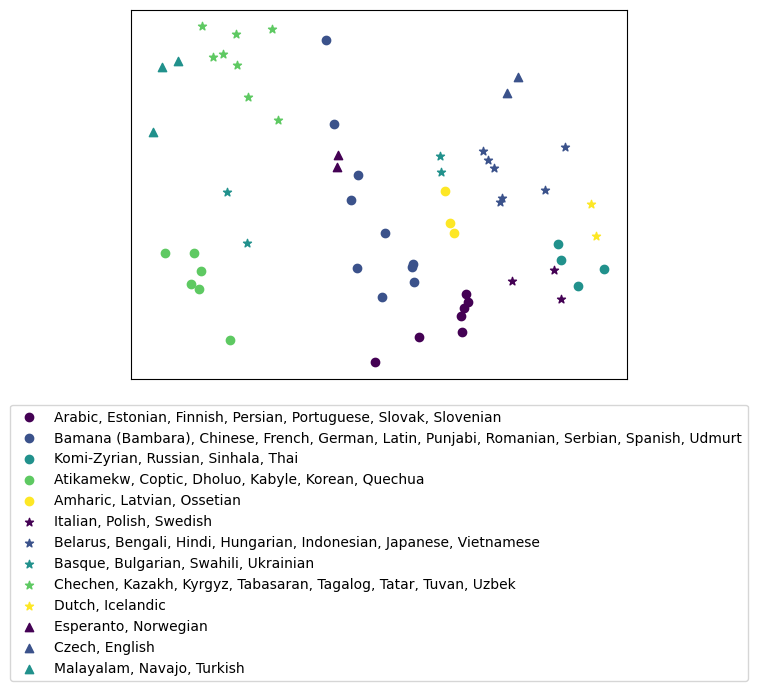

In [12]:
k = 0

for n in (1, 2, 3):
    for d in (5, 10, 15):
        if n == 3 and d != 15: continue

        labels = labels_id[k]

        X = id[(id.n == n) & (id.d == d)].drop(['n', 'd'], axis=1)

        languages = X.language.values

        X = TSNE().fit_transform(X.drop('language', axis=1).values)

        markers = ('o', '*', '^')#, 's')
        colours = matplotlib.cm.viridis(np.linspace(0, 1, int(np.ceil(len(set(labels)) / len(markers)))))

        cluster_num = 1
        for marker in markers:
            for colour in colours:
                cluster = X[labels == cluster_num]
                plt.scatter(cluster[:, 0], cluster[:, 1], color=colour, marker=marker, label=', '.join(languages[labels == cluster_num]))
                cluster_num += 1

        plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.05))
        plt.xticks([])
        plt.yticks([])

        plt.savefig(f'ID_{n}-{d}.png', dpi=450, bbox_inches='tight')
        plt.show()

        k += 1